# Machine Learning Engineer Nanodegree
## Model Evaluation & Validation
## Project: Predicting Boston Housing Prices

### Read the housing dataset and show the first 5 lines

In [1]:
# Import libraries necessary for this project
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import visuals as vs  # Supplementary code
from sklearn.model_selection import ShuffleSplit

# Pretty display for notebooks
%matplotlib inline

#### Read the data saved in the same location and display it

In [2]:
# Load the Boston housing dataset
data = pd.read_csv('housing.csv')
data.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


* Gathering all information about the dataset: types, shape, statistics, and a check of `MEDV` for outliers / missing values

RM         float64
LSTAT      float64
PTRATIO    float64
MEDV       float64
dtype: object

Shape: (489, 4)

Missing values per column:
 RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64


,RM,LSTAT,PTRATIO,MEDV
count,489.000000,489.000000,489.000000,4.890000e+02
mean,6.240288,12.939632,18.516564,4.543429e+05
std,0.643650,7.081990,2.111268,1.653403e+05
min,3.561000,1.980000,12.600000,1.050000e+05
25%,5.880000,7.370000,17.400000,3.507000e+05
50%,6.185000,11.690000,19.100000,4.389000e+05
75%,6.575000,17.120000,20.200000,5.187000e+05
max,8.398000,37.970000,22.000000,1.024800e+06


MEDV statistics:
 count    4.890000e+02
mean     4.543429e+05
std      1.653403e+05
min      1.050000e+05
25%      3.507000e+05
50%      4.389000e+05
75%      5.187000e+05
max      1.024800e+06
Name: MEDV, dtype: float64

MEDV outliers (1.5*IQR rule): 22


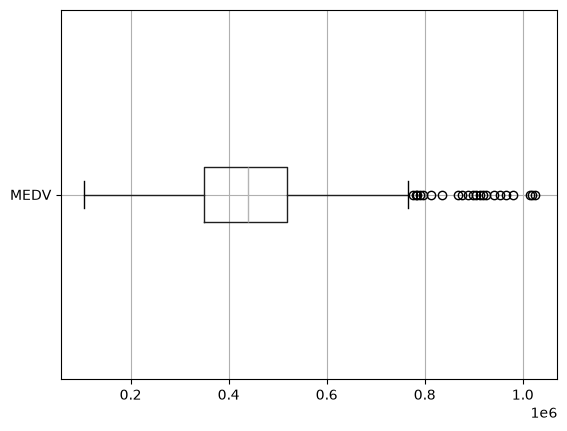

In [3]:
# 1- type of all data
print(data.dtypes)

# shape of the data
print("\nShape:", data.shape)

# missing values
print("\nMissing values per column:\n", data.isnull().sum())

# basic statistics
display(data.describe())

# statistics of the prediction column
print("MEDV statistics:\n", data['MEDV'].describe())

# outliers in MEDV using the 1.5 * IQR rule
q1, q3 = data['MEDV'].quantile([0.25, 0.75])
iqr = q3 - q1
mask = (data['MEDV'] < q1 - 1.5 * iqr) | (data['MEDV'] > q3 + 1.5 * iqr)
print("\nMEDV outliers (1.5*IQR rule):", mask.sum())
data.boxplot(column='MEDV', vert=False);

**Observations:** all four columns are `float64`, there are 489 rows and **no missing values**. `MEDV` ranges from $105,000 to $1,024,800; the IQR rule flags a small number of points (mostly expensive neighborhoods) as outliers, which are real values and are kept.

In [4]:
prices = data['MEDV']
features = data.drop('MEDV', axis=1)
# print the shape of the data
print('Boston housing dataset has {0} data points with {1} variables each.'.format(*data.shape))

Boston housing dataset has 489 data points with 4 variables each.


## Data Exploration
### Implementation: Calculate Statistics

In [5]:
# Minimum price of the data
minimum_price = np.min(prices)

# Maximum price of the data
maximum_price = np.max(prices)

# Mean price of the data
mean_price = np.mean(prices)

# Median price of the data
median_price = np.median(prices)

# Mode of the prices
mode_price = prices.mode()[0]

# Standard deviation of prices of the data
std_price = np.std(prices)

# Show the calculated statistics
print("Statistics for Boston housing dataset:\n")
print("Minimum price: ${:,.2f}".format(minimum_price))
print("Maximum price: ${:,.2f}".format(maximum_price))
print("Mean price: ${:,.2f}".format(mean_price))
print("Median price ${:,.2f}".format(median_price))
print("Mode price: ${:,.2f}".format(mode_price))
print("Standard deviation of prices: ${:,.2f}".format(std_price))

Statistics for Boston housing dataset:

Minimum price: $105,000.00
Maximum price: $1,024,800.00
Mean price: $454,342.94
Median price $438,900.00
Mode price: $525,000.00
Standard deviation of prices: $165,171.13


### Question 1 - Feature Observation

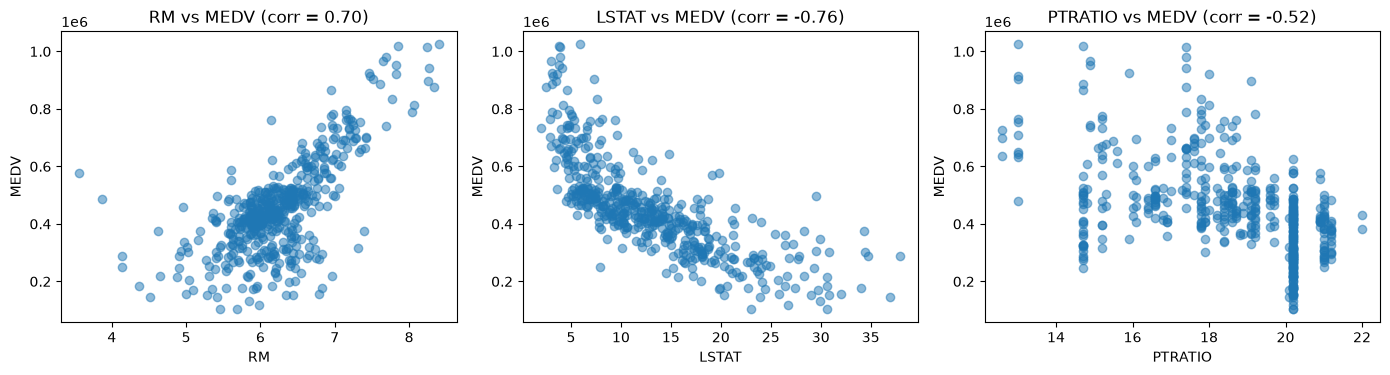

In [6]:
# Supporting evidence for the answer below
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, features.columns):
    ax.scatter(features[col], prices, alpha=0.5)
    ax.set_xlabel(col); ax.set_ylabel('MEDV')
    ax.set_title('{} vs MEDV (corr = {:.2f})'.format(col, features[col].corr(prices)))
plt.tight_layout(); plt.show()

### Answer 1:
* **RM** (average rooms): an **increase** in RM should **increase** MEDV. More rooms means bigger homes, and a home with 7 rooms should be worth more than one with 6. (Correlation with MEDV ≈ +0.70.)
* **LSTAT** (% lower-class homeowners): an **increase** in LSTAT should **decrease** MEDV. Neighborhoods with a lower-income population generally have lower house prices, so LSTAT 15 should be worth more than LSTAT 20. (Correlation ≈ −0.76, the strongest.)
* **PTRATIO** (students per teacher): an **increase** in PTRATIO should **decrease** MEDV. Fewer students per teacher usually means better-funded schools, which families pay more for, so PTRATIO 10 should be worth more than PTRATIO 15. (Correlation ≈ −0.52.)

The scatter plots confirm all three directions.

## Developing a Model
### Implementation: Define a Performance Metric (R² score)

In [7]:
from sklearn.metrics import r2_score

def performance_metric(y_test, y_predict):
    """ Calculates and returns the performance score between
        test and predicted values based on the metric chosen. """
    score = r2_score(y_test, y_predict)
    return score

### Question 2 - Goodness of Fit

In [8]:
score = performance_metric([3, -0.5, 2, 7, 4.2], [2.5, 0.0, 2.1, 7.8, 5.3])
print("Model has a coefficient of determination, R^2, of {:.3f}.".format(score))

Model has a coefficient of determination, R^2, of 0.923.


### Answer 2:
Yes. R² = **0.923**, so about 92.3% of the variance of the target is explained by the model's predictions. That is close to 1, and the individual predictions are all within about 1.1 of the true values, so the model has captured most of the variation. (With only five points this is a small sample, so it is a demonstration rather than strong evidence.)

### Implementation: Shuffle and Split Data

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, prices, test_size=0.2, random_state=1)

print("Training and testing split was successful.")
print(X_train.shape, X_test.shape)

Training and testing split was successful.
(391, 3) (98, 3)


### Question 3 - Training and Testing
### Answer 3:
Splitting lets us evaluate the model on data it has **never seen**. Scoring on the training data only tells us how well the model memorized it. A held-out test set gives an honest estimate of how it will generalize, which exposes **overfitting** (great training score, poor test score). Shuffling before the split removes ordering bias. The split ratio matters too: too little training data causes underfitting, and too little test data makes the performance estimate noisy.

## Analyzing Model Performance
### Learning Curves

In [10]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve, ShuffleSplit, train_test_split
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

def ModelLearning(X, y):
    """Calculates the performance of several models with varying sizes of training data.
       The learning and testing scores for each model are then plotted."""
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
    train_sizes = np.rint(np.linspace(1, X.shape[0] * 0.8 - 1, 9)).astype(int)
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    for k, depth in enumerate([1, 3, 6, 10]):
        regressor = DecisionTreeRegressor(max_depth=depth)
        sizes, train_scores, test_scores = learning_curve(
            regressor, X, y, cv=cv, train_sizes=train_sizes, scoring='r2')
        train_mean = np.mean(train_scores, axis=1); train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1);   test_std = np.std(test_scores, axis=1)
        ax = axes[k//2, k%2]
        ax.plot(sizes, train_mean, 'o-', color='r', label='Training Score')
        ax.plot(sizes, test_mean, 'o-', color='g', label='Testing Score')
        ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='r')
        ax.fill_between(sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='g')
        ax.set_title(f'max_depth = {depth}')
        ax.set_xlabel('Number of Training Points'); ax.set_ylabel('Score')
        ax.set_xlim([0, X.shape[0] * 0.8]); ax.set_ylim([-0.05, 1.05])
        ax.legend(loc='lower right')
    fig.suptitle('Decision Tree Regressor Learning Performances', fontsize=16, y=1.03)
    fig.tight_layout()
    plt.show()

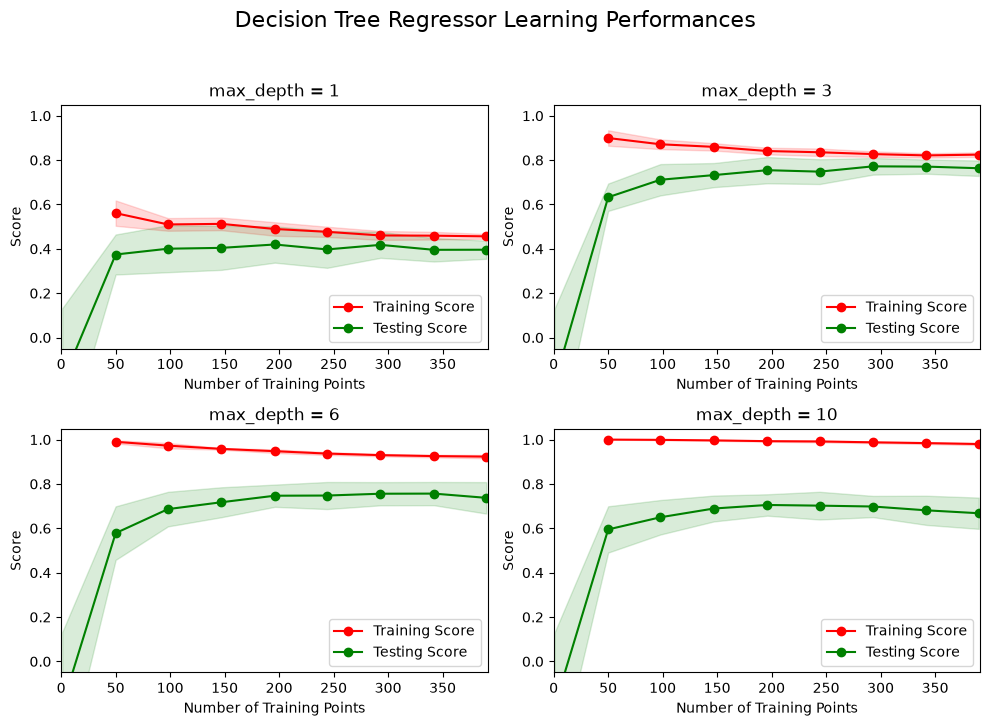

In [11]:
ModelLearning(features, prices)

### Question 4 - Learning the Data
### Answer 4:
Take the graph with **max_depth = 3**. As training points are added, the **training score decreases** (it is easy to fit a few points perfectly, harder to fit many) while the **testing score increases**. The training score falls from about 0.9 to about 0.82 and the testing score rises to about 0.76, so the two curves converge at roughly **0.75–0.8** with a small gap. Because the curves have already flattened, **adding more training points would not help much**: the model is limited by its complexity (bias), not by lack of data. (For max_depth = 1 both curves plateau lower, around 0.4, which is clear underfitting. For max_depth = 10 the training score stays near 1 while the testing score stays well below it, which is overfitting, and more data would help there.)

### Complexity Curves

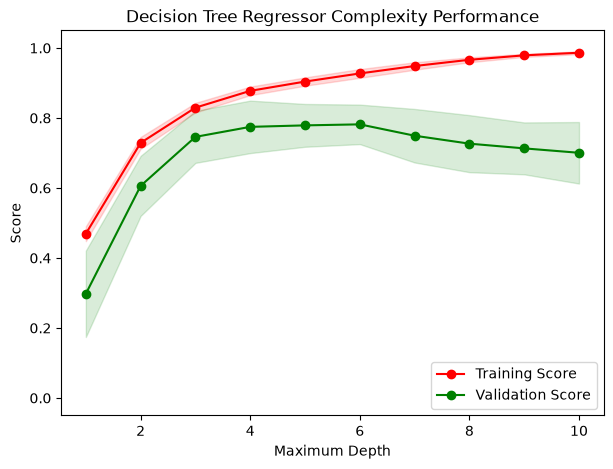

In [12]:
vs.ModelComplexity(X_train, y_train)

### Question 5 - Bias-Variance Tradeoff
### Answer 5:
* **max_depth = 1: high bias (underfitting).** Both the training and validation scores are low (about 0.47 and 0.30) and close together. The model is too simple to capture the structure of the data.
* **max_depth = 10: high variance (overfitting).** The training score is almost perfect (about 0.99) while the validation score is clearly lower (about 0.70) and has dropped from its peak. The large gap between the two curves shows the model memorizes the training data and does not generalize.

### Question 6 - Best-Guess Optimal Model
### Answer 6:
A **max_depth of 4** (5 and 6 are almost identical). The validation score peaks at about 0.78 around depths 4–6 and then declines, while the training score keeps climbing, so the gap only widens beyond that. By Occam's razor I would choose the simplest model that reaches the peak, which is depth 4.

## Evaluating Model Performance
### Question 7 - Cross-Validation
### Answer 7:
**k-fold cross-validation** splits the training data into *k* equal folds. The model is trained *k* times; each time one fold is held out as the validation set and the other *k−1* folds are used for training. The *k* scores are averaged to give the final estimate, so every data point is used for both training and validation exactly once.

For **grid search**, a single fixed train/validation split can make a parameter combination look good or bad just by luck of that split, and it wastes data. With k-fold CV each parameter combination is scored on *k* different splits, so the chosen hyperparameters are more reliable, less prone to overfitting one validation set, and the data are used efficiently.

### Implementation: Fitting a Model

In [13]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV   # (sklearn.grid_search was removed)

def fit_model(X, y):
    """ Performs grid search over the 'max_depth' parameter for a
        decision tree regressor trained on the input data [X, y]. """

    # Create cross-validation sets from the training data
    cv_sets = ShuffleSplit(n_splits=10, test_size=0.20, random_state=0)

    regressor = DecisionTreeRegressor(random_state=0)
    params = {'max_depth': list(range(1, 11))}
    scoring_fnc = make_scorer(performance_metric)
    grid = GridSearchCV(regressor, params, scoring=scoring_fnc, cv=cv_sets)

    # Fit the grid search object to the data to compute the optimal model
    grid = grid.fit(X, y)

    # Return the optimal model after fitting the data
    return grid.best_estimator_

### Question 9 - Optimal Model

In [14]:
# Fit the training data to the model using grid search
reg = fit_model(X_train, y_train)

# Produce the value for 'max_depth'
print("Parameter 'max_depth' is {} for the optimal model.".format(reg.get_params()['max_depth']))

# Bonus: score on the held-out test set
print("R^2 on the test set: {:.3f}".format(performance_metric(y_test, reg.predict(X_test))))

Parameter 'max_depth' is 6 for the optimal model.
R^2 on the test set: 0.788


### Answer 9:
The grid search selects **max_depth = 6**. This is a bit higher than my guess of 4 in Question 6, but the complexity curve shows depths 4, 5 and 6 have almost the same validation score (about 0.78), so the guess was reasonable; the grid search simply picked the best of these near-ties.

### Question 10 - Predicting Selling Prices

In [15]:
# Matrix for client data, using the values from the table above
# (RM, LSTAT, PTRATIO)
client_data = pd.DataFrame([[5, 17, 15],   # Client 1
                            [4, 32, 22],   # Client 2
                            [8, 3, 12]],   # Client 3
                           columns=features.columns)

# Show predictions
for i, price in enumerate(reg.predict(client_data)):
    print("Predicted selling price for Client {}'s home: ${:,.2f}".format(i+1, price))

Predicted selling price for Client 1's home: $424,935.00
Predicted selling price for Client 2's home: $284,200.00
Predicted selling price for Client 3's home: $933,975.00


### Answer 10:
Recommended selling prices (from the model above) are roughly **Client 1 ≈ $425,000, Client 2 ≈ $284,000, Client 3 ≈ $934,000**.

These look reasonable. Client 3 has the most rooms, the lowest poverty level and the best schools, so the highest price. Client 2 has the fewest rooms, the highest poverty level and the worst student–teacher ratio, so the lowest price. Client 1 sits in between. Compared with the dataset statistics (mean ≈ $454k, median ≈ $439k, range $105k–$1.02M), Client 1 is near the middle of the market, Client 2 falls in the lower part, and Client 3 is near the top of the range, as expected from their features.

*Note:* the code cell in the original notebook used client values (34, 55, 7) for LSTAT that did not match this table (17%, 32%, 3%); I used the table's values.

### Sensitivity (uses `vs.PredictTrials` from visuals.py)

In [16]:
vs.PredictTrials(features, prices, fit_model, client_data.values)

Trial 1: $391,183.33
Trial 2: $424,935.00
Trial 3: $415,800.00
Trial 4: $420,622.22
Trial 5: $418,377.27
Trial 6: $411,931.58
Trial 7: $399,663.16
Trial 8: $407,232.00
Trial 9: $351,577.61
Trial 10: $413,700.00

Range in prices: $73,357.39


Across the 10 trials the predicted price for Client 1 ranges from about $352k to $425k (a spread of roughly $73k), so the model is somewhat sensitive to the training data. Use it as a guide for pricing, not as an exact value.